In [9]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from pathlib import Path

from src.data import *
from src.models import *
from src.visualization import *
from src.train_utils import *

In [10]:
DATA_SPLIT_SEED = 42
SEED = 42
BATCH_SIZE = 128
EPOCHS = 35
PATIENCE = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.1
TEST_SIZE = 0.1
DATA_PATH = "dataset.tsv"
MODEL_CLASS = DeepSTARRRDSEB
USE_RC_TTA_TEST_EVALUATION = True
NORMALIZED_PREDICTION_USED = True
CHECKPOINT_DIR = Path(f"models/{MODEL_CLASS.__name__}")
CHECKPOINT_DIR.mkdir(exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() 
            else 'mps' if torch.backends.mps.is_available() 
            else 'cpu')
print(f'DEVICE: {DEVICE}')

DEVICE: mps


In [ ]:
df = load_data(DATA_PATH)
train_df, val_df, test_df = split_data(df=df, seed=DATA_SPLIT_SEED, test_size=TEST_SIZE, val_size=VAL_SIZE)
mean, std = None, None
if NORMALIZED_PREDICTION_USED:
    train_df, mean, std = normalize_rna_dna_ratio(train_df)
train_loader, val_loader, test_loader = make_loaders(train_df, val_df, test_df, mean, std, batch_size=BATCH_SIZE, seed=DATA_SPLIT_SEED)

print(f'train: {len(train_df)} | val: {len(val_df)} | test: {len(test_df)}')
print(f'mean: {mean:.4f} | std: {std:.4f}')

train: 44308 | val: 5539 | test: 5539


In [ ]:
model, optimizer, scheduler = build_model(seed=SEED, model_class=MODEL_CLASS, device=DEVICE,
                                           learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

train(seed=SEED,
      model=model, optimizer=optimizer, scheduler=scheduler, device=DEVICE,
      train_loader=train_loader, val_loader=val_loader, epochs=EPOCHS, patience=PATIENCE, 
      ckpt_path=CHECKPOINT_DIR / f"model_seed{SEED}.pt", 
      meta_path=CHECKPOINT_DIR / f"model_seed{SEED}_meta.json",
      mean=mean, std=std)

/Users/domi/Documents/studia/08_sem/deep_learning_in_life_science/dr448657/src/visualization.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state = torch.load(ck


===== Test =====
Loss:     0.2284
MSE:      0.3138
Pearson:  0.6966
Spearman: 0.6817
Accuracy: 0.7989


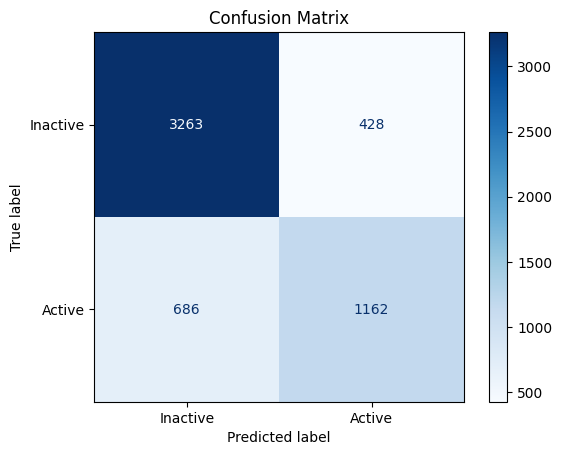

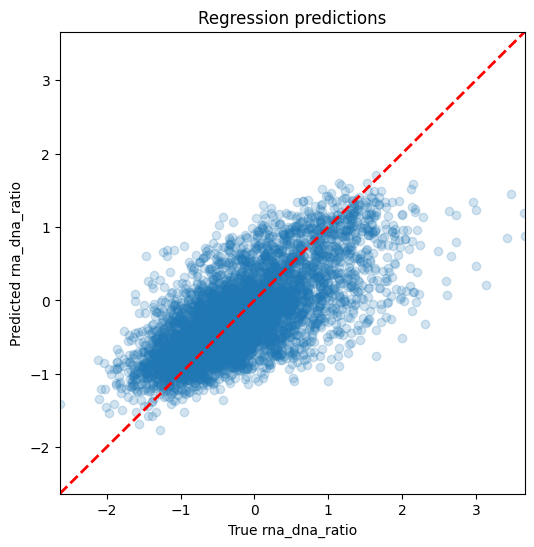

In [12]:
model = load_model(model_class=MODEL_CLASS, device=DEVICE, ckpt_path=CHECKPOINT_DIR / f"model_seed{SEED}.pt")
metrics = evaluate_model(
    model=model,
    loader=test_loader,
    device=DEVICE,
    normalized_prediction_used=NORMALIZED_PREDICTION_USED,
    mean=mean,
    std=std,
    use_rc_tta=USE_RC_TTA_TEST_EVALUATION,
)
print_metrics(metrics, set_name="Test")
plot_confusion_matrix(metrics["y_true_active"], metrics["y_pred_active"])
plot_regression(metrics["y_true_rna_dna_ratio"], metrics["y_pred_rna_dna_ratio"])